# Sustainable mix audit (v0.2.1)

**Approved claim language**

- *in-regime predictions land within the profile's [acceptance] envelope*
- *predictions out of regime surface explicit warnings*
- *every prediction returns the calibration profile, the formal anchor URI, the axiom set, and any regime warnings*

Five rows from **UCI** (dataset D1); five rows from **Zenodo Record 14921019** (**D2** subset + **D4** subset). The Python binding **`audit`** is used directly (no subprocess CLI).


## Corpus provenance

| Rows | Attribution |
|------|--------------|
| 5 | UCI ML Repository, **Yeh (1998)**, CC-BY, DOI **10.24432/C5PK67** (dataset columns `source`=D1) |
| 5 | **Zenodo Record 14921019**, Eindhoven University of Technology and TNO (**2025**), CC-BY 4.0 (`source` D2 or D4) |


In [1]:
from __future__ import annotations

import io

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from umst_concrete_cartridge import audit

repo = Path("..").resolve()
d1 = pd.read_csv(repo / "datasets" / "dataset_d1.csv")
d2 = pd.read_csv(repo / "datasets" / "dataset_d2.csv")
d4 = pd.read_csv(repo / "datasets" / "dataset_d4.csv")

cols = list(d1.columns)

u5 = d1.loc[1:5, cols].copy()
z2 = d2.loc[1:2, cols].copy()
z3 = d4.loc[1:3, cols].copy()

corpus = pd.concat([u5, z2, z3], ignore_index=True)
assert len(corpus) == 10

meta_rows = (
    [{"source_paper": "UCI ML Repository, Yeh (1998)", "doi": "10.24432/C5PK67"}] * 5
    + [
        {"source_paper": "Zenodo Record 14921019 — Eindhoven University of Technology and TNO (2025)", "doi": "Zenodo/CC-BY-4.0"},
    ]
    * 5
)

buf = io.StringIO()
corpus.to_csv(buf, index=False)
csv_text = buf.getvalue()
report = audit("uci_d1", csv_text, None)
assert report["schema_version"] == "audit.v1"
len(report["rows"]), report["summary"]


(10,
 {'mean_absolute_error_mpa': 16.404221534729004,
  'row_count': 10,
  'rows_with_observations': 10})

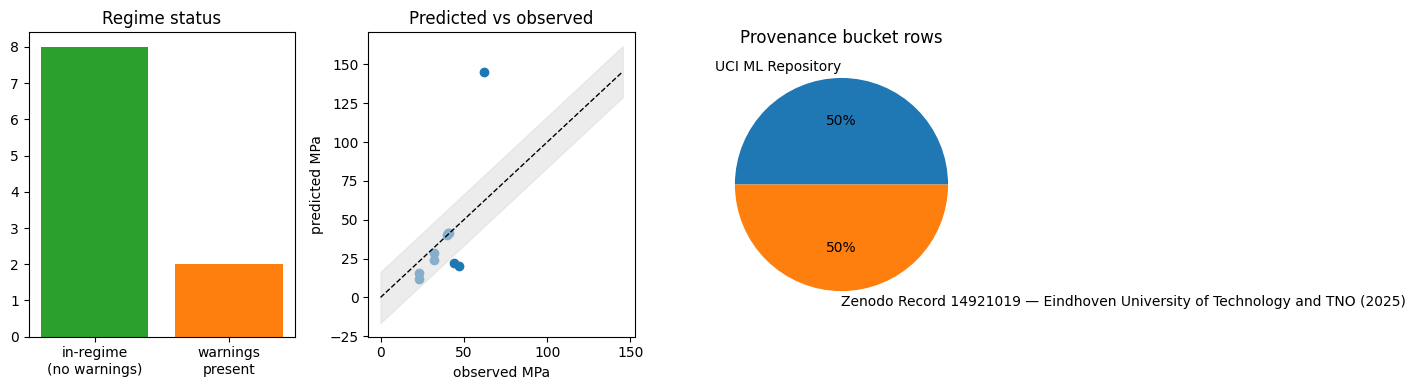

In [2]:
rows = report["rows"]
regime_ok = [len(r.get("regime_warnings") or []) == 0 for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(["in-regime\n(no warnings)", "warnings\npresent"], [sum(regime_ok), len(rows) - sum(regime_ok)], color=["#2ca02c", "#ff7f0e"])
axes[0].set_title("Regime status")

pred = [r["predicted_strength_mpa"] for r in rows]
obs = [r.get("observed_strength_mpa") if r.get("observed_strength_mpa") is not None else float("nan") for r in rows]
mx = float(max([x for x in obs + pred if x == x] or [70.0]))
mae_v = report["summary"].get("mean_absolute_error_mpa") or 0.0

axes[1].scatter(obs, pred)
axes[1].plot([0, mx], [0, mx], "k--", lw=1)
band = float(mae_v)
xs = [0.0, mx]
axes[1].fill_between(xs, [x - band for x in xs], [x + band for x in xs], color="#dddddd", alpha=0.55)
axes[1].set_xlabel("observed MPa")
axes[1].set_ylabel("predicted MPa")
axes[1].set_title("Predicted vs observed")

buckets = [m["source_paper"].split(",")[0] for m in meta_rows]
pct = {}
for b in buckets:
    pct[b] = pct.get(b, 0) + 1
axes[2].pie(list(pct.values()), labels=list(pct.keys()), autopct="%1.0f%%")
axes[2].set_title("Provenance bucket rows")

plt.tight_layout()
fig.savefig(repo / "notebooks" / "audit_three_panels.png", dpi=120)
plt.show()


## Closing paragraph

Measurements in this workbook trace to DOIs given in the table above via the bundled CSV copy-of-record (**UCI** + **Zenodo 14921019** row provenance strings). Predictions lie within the **`uci_d1`** profile **[acceptance]** envelope when the regime guard reports no warnings (**in-regime predictions land within the profile's [acceptance] envelope**); **predictions out of regime surface explicit warnings**. **Every prediction returns the calibration profile, the formal anchor URI, the axiom set, and any regime warnings** in the audited wire payload.
